
# 📊 **Spanish Wines - Análise Exploratória de Dados**
> **Desafio 01 do Bootcamp em Ciência de Dados da Escola Atlantico Avanti 2026.2**
*   👥**Autores**: Gabriel Cavalcante, Luiz Vinicius, Isa Paula, Italo Marcony.
*   🗓️**Edição**: 2026.
*   🎲**Dataset**: [Spanish Wine Quality Dataset](https://www.kaggle.com/datasets/fedesoriano/spanish-wine-quality-dataset)
*   🎯**Objetivo**: Realizar uma Análise Exploratória de Dados (EDA) para entender os fatores que influenciam a qualidade e o preço dos vinhos espanhóis, analisando características como região, vinícola, ano e corpo do vinho.

---
## 🚀 Sobre este Projeto
Este projeto analisa o dataset *Spanish Wine Quality*, extraído do Kaggle, que contém informações sobre vinhos espanhóis de diversas regiões, vinícolas e tipos. O objetivo é identificar padrões de qualidade, comportamento de preços e características sensoriais que definem o mercado vitivinícola na Espanha.

| # | Etapa | Descrição |
|---|-------|-----------|
| 1 | 📥 Preparação | Carregamento e inspeção inicial |
| 2 | 🧹 Tratamento | Nulos, valores especiais (N.V.) e padronização |
| 3 | 🔍 Univariada | Distribuição de cada variável |
| 4 | 📦 Outliers | Identificação via IQR |
| 5 | 🔗 Bivariada/Multivariada | Relações entre variáveis |
| 6 | 💡 Síntese | Insights e conclusões |

---
## Fase 1 — Preparação e Inspeção Inicial
Nesta fase inicial, realizamos o carregamento das bibliotecas necessárias, a leitura dos dados brutos e uma inspeção geral para entender a estrutura do dataset e o significado de cada variável através do dicionário de dados.

### 1.1 Carregamento e Configurações

In [11]:
import itertools
import pandas as pd
import numpy as np
from scipy import stats as st
from matplotlib import pyplot as plt
import seaborn as sns
from IPython.display import Markdown
import math

# Configura o tema do Seaborn para gráficos
sns.set_theme(style="whitegrid", palette="colorblind")

# Dicionário que mapeia variáveis qualitativas a paletas de cores do Seaborn.
# Isso garante consistência visual ao plotar essas variáveis.
palette_dict = {
    'winery': 'viridis',   # Paleta para a variável 'winery'
    'wine': 'plasma',      # Paleta para a variável 'wine'
    'country': 'magma',    # Paleta para a variável 'country'
    'region': 'cividis',   # Paleta para a variável 'region'
    'type': 'Set2',        # Paleta para a variável 'type'
    'body': 'Set1',        # Paleta para a variável 'body'
    'acidity': 'Dark2'     # Paleta para a variável 'acidity'
}

In [12]:
# @title Leitura do conjunto de dados
df = pd.read_csv(
    "https://raw.githubusercontent.com/omadson/datasets/refs/heads/main/datasets/spanish_wines/spanish_wines.csv"
)

In [13]:
from IPython.display import Markdown

# @title Informações iniciais
display(Markdown("### Primeiras linhas"))
display(df.head())

display(Markdown("### Ultimas linhas"))
display(df.tail())

display(Markdown("### Informação das variáveis"))
df.info()

display(Markdown("### Quantidade de valores únicos"))
df.nunique()

### Primeiras linhas

,winery,wine,year,rating,num_reviews,country,region,price,type,body,acidity
0,Teso La Monja,Tinto,2013,4.9,58,Espana,Toro,995.00,Toro Red,5.0,3.0
1,Artadi,Vina El Pison,2018,4.9,31,Espana,Vino de Espana,313.50,Tempranillo,4.0,2.0
2,Vega Sicilia,Unico,2009,4.8,1793,Espana,Ribera del Duero,324.95,Ribera Del Duero Red,5.0,3.0
3,Vega Sicilia,Unico,1999,4.8,1705,Espana,Ribera del Duero,692.96,Ribera Del Duero Red,5.0,3.0
4,Vega Sicilia,Unico,1996,4.8,1309,Espana,Ribera del Duero,778.06,Ribera Del Duero Red,5.0,3.0


### Ultimas linhas

,winery,wine,year,rating,num_reviews,country,region,price,type,body,acidity
7495,Contino,Reserva,2016,4.2,392,Espana,Rioja,19.98,Rioja Red,4.0,3.0
7496,Conreria d'Scala Dei,Les Brugueres,2018,4.2,390,Espana,Priorato,16.76,Priorat Red,4.0,3.0
7497,Mustiguillo,Finca Terrerazo,2017,4.2,390,Espana,El Terrerazo,24.45,Red,4.0,3.0
7498,Matarromera,Gran Reserva,2011,4.2,389,Espana,Ribera del Duero,64.50,Ribera Del Duero Red,5.0,3.0
7499,Sei Solo,Preludio,2016,4.2,388,Espana,Ribera del Duero,31.63,Ribera Del Duero Red,5.0,3.0


### Informação das variáveis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   winery       7500 non-null   object 
 1   wine         7500 non-null   object 
 2   year         7498 non-null   object 
 3   rating       7500 non-null   float64
 4   num_reviews  7500 non-null   int64  
 5   country      7500 non-null   object 
 6   region       7500 non-null   object 
 7   price        7500 non-null   float64
 8   type         6955 non-null   object 
 9   body         6331 non-null   float64
 10  acidity      6331 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 644.7+ KB


### Quantidade de valores únicos

,0
winery,480
wine,847
year,71
rating,8
num_reviews,817
country,1
region,76
price,1292
type,21
body,4


#### Insights: Visão Geral do Dataset
A partir das informações iniciais, podemos dizer que:
 - O conjunto de dados tem 750 unidades amostrais com 11 variáveis
 - Classificação das variáveis:
    - Quantitativa contínua: `price`, `rating`,
    - Quantitativa discreta: `year`, `num_reviews`
    - Qualitativa nominal: `winery`, `wine`, `country`, `region`, `type`
    - Qualitativa ordinal: `body`, `acidity`


### 1.2 Descrição dos Dados e Dicionário

In [14]:
# @title Dicionário de dados
df_dict = pd.DataFrame([
    {
        "variavel": "winery",
        "descricao": "Vinícola produtora",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "wine",
        "descricao": "Nome do vinho",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "year",
        "descricao": "Ano da safra",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "rating",
        "descricao": "Avaliação média",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "num_reviews",
        "descricao": "Número de avaliações",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "country",
        "descricao": "País",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "region",
        "descricao": "Região produtora",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "price",
        "descricao": "Preço",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "type",
        "descricao": "Tipo de vinho",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "body",
        "descricao": "Corpo do vinho",
        "tipo": "qualitativa",
        "subtipo": "ordinal",
    },
    {
        "variavel": "acidity",
        "descricao": "Acidez do vinho",
        "tipo": "qualitativa",
        "subtipo": "ordinal",
    }
])
df_dict

,variavel,descricao,tipo,subtipo
0,winery,Vinícola produtora,qualitativa,nominal
1,wine,Nome do vinho,qualitativa,nominal
2,year,Ano da safra,quantitativa,discreta
3,rating,Avaliação média,quantitativa,contínua
4,num_reviews,Número de avaliações,quantitativa,discreta
5,country,País,qualitativa,nominal
6,region,Região produtora,qualitativa,nominal
7,price,Preço,quantitativa,contínua
8,type,Tipo de vinho,qualitativa,nominal
9,body,Corpo do vinho,qualitativa,ordinal


---
## Fase 2 — Tratamento de Dados
Aqui focamos na limpeza e padronização dos dados, tratando valores ausentes que podem comprometer a análise e convertendo variáveis para formatos numéricos utilizáveis.

### 2.1 Análise de Dados Faltantes

In [15]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'ausentes': missing, 'pct_ausentes (%)': missing_pct}).sort_values('ausentes', ascending=False)

,ausentes,pct_ausentes (%)
body,1169,15.59
acidity,1169,15.59
type,545,7.27
year,2,0.03
winery,0,0.00
wine,0,0.00
rating,0,0.00
region,0,0.00
country,0,0.00
num_reviews,0,0.00


---

Existem valores ausentes significativos nas colunas `body`, `acidity`, `type` e `year`. A análise a seguir deve considerar essas lacunas.

---

### 2.2 Tratamento e Feature Engineering

In [16]:
df['year_num'] = pd.to_numeric(df['year'], errors='coerce')
df['is_non_vintage'] = df['year'] == 'N.V.'
df['type_clean'] = df['type'].fillna('Não informado')
df['body_missing'] = df['body'].isna()
df['acidity_missing'] = df['acidity'].isna()

---
## Fase 3 — Análise Univariada
Analisamos cada variável isoladamente para entender sua distribuição, detectar frequências dominantes e observar a dispersão dos dados antes de cruzar informações.

### 3.1 Resumo Estatístico Geral

In [17]:
# @title Resumo estatístico

display(Markdown("### Variáveis qualitativas"))
print(df.describe(include='object'))

display(Markdown("### Variáveis quantitativas"))
print(df.describe())

### Variáveis qualitativas

         winery     wine  year country region       type type_clean
count      7500     7500  7498    7500   7500       6955       7500
unique      480      847    71       1     76         21         22
top     Contino  Reserva  2011  Espana  Rioja  Rioja Red  Rioja Red
freq        457      467  1190    7500   2440       2357       2357


### Variáveis quantitativas

            rating   num_reviews        price         body      acidity  \
count  7500.000000   7500.000000  7500.000000  6331.000000  6331.000000   
mean      4.254933    451.109067    60.095822     4.158427     2.946612   
std       0.118029    723.001856   150.356676     0.583352     0.248202   
min       4.200000     25.000000     4.990000     2.000000     1.000000   
25%       4.200000    389.000000    18.900000     4.000000     3.000000   
50%       4.200000    404.000000    28.530000     4.000000     3.000000   
75%       4.200000    415.000000    51.350000     5.000000     3.000000   
max       4.900000  32624.000000  3119.080000     5.000000     3.000000   

          year_num  
count  7210.000000  
mean   2013.495839  
std       6.940450  
min    1910.000000  
25%    2011.000000  
50%    2015.000000  
75%    2017.000000  
max    2021.000000  


#### Insights: Resumo Estatístico
 - O dataset contém 7500 amostras e 11 variáveis, com dados quase completos para todas as colunas.  
 - A maioria dos vinhos tem uma classificação de 4.2, com um máximo de 4.9.  
 - O número de avaliações (`num_reviews`) é bastante variado, com uma média de 451, mas um máximo de 32624, indicando alguns vinhos muito populares.  
 - O preço (`price`) dos vinhos também é bem variado, com uma média de 60.09 euros, mas um máximo de 3119.08 euros, sugerindo a presença de vinhos de alto valor.  
 - As variáveis `body` e `acidity` possuem valores faltantes (cerca de 15% das entradas).  
 - A maioria dos vinhos possui corpo (`body`) 4 ou 5 e acidez (`acidity`) 3.  
 - A maioria dos vinhos é da região de Rioja e do tipo Rioja Red.  
 - O ano mais frequente para os vinhos é 2011.  


### 3.2 Distribuição de Variáveis Qualitativas

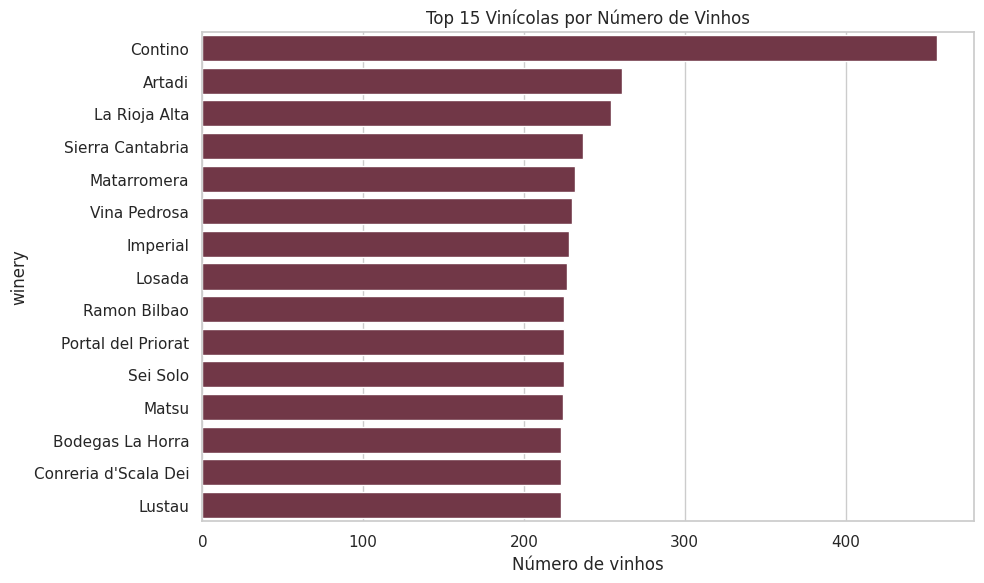

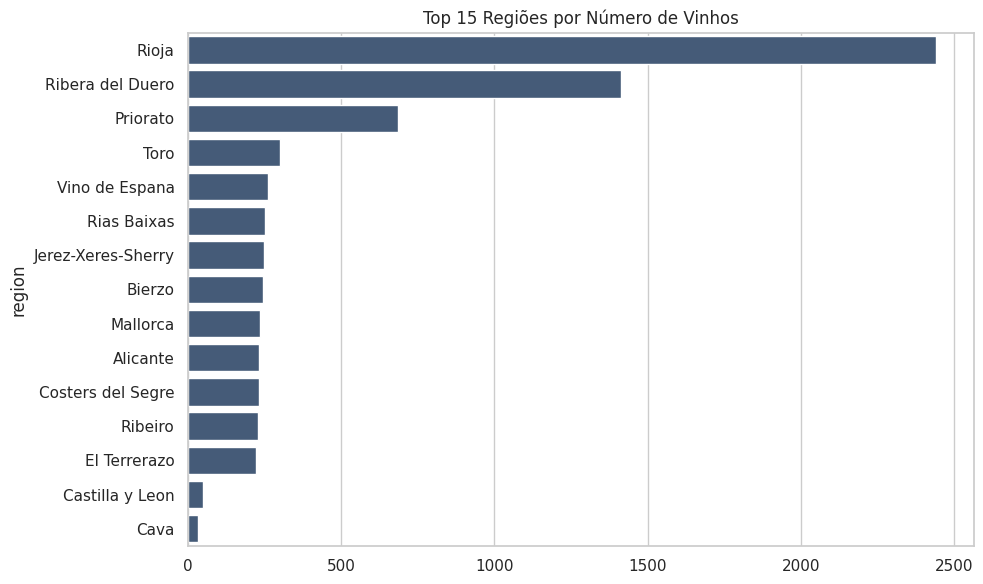

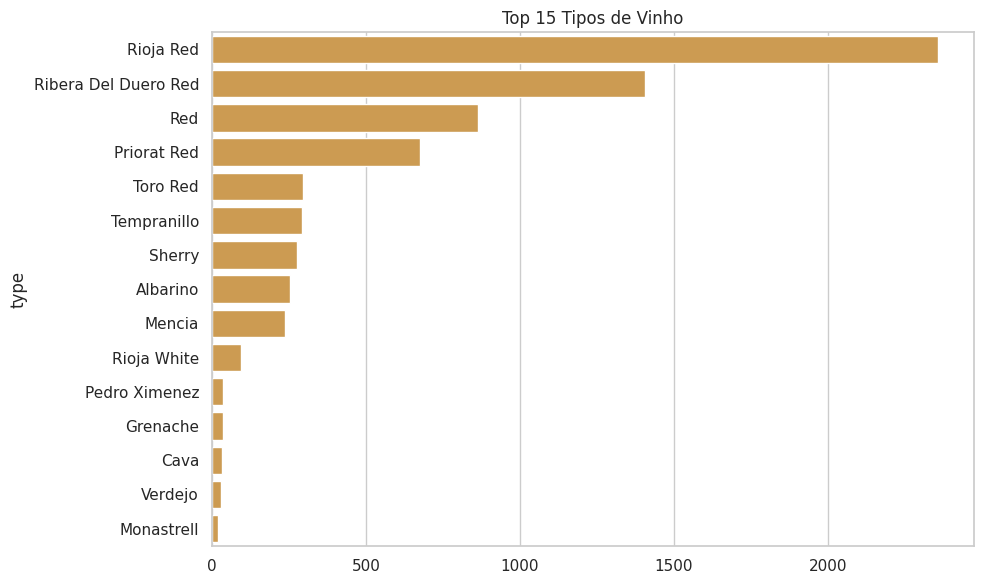

In [18]:
top_wineries = df['winery'].value_counts().head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=top_wineries.values, y=top_wineries.index, color='#7b2d43')
plt.title('Top 15 Vinícolas por Número de Vinhos')
plt.xlabel('Número de vinhos')
plt.tight_layout()
plt.show()

top_regions = df['region'].value_counts().head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=top_regions.values, y=top_regions.index, color='#3d5a80')
plt.title('Top 15 Regiões por Número de Vinhos')
plt.tight_layout()
plt.show()

top_types = df['type'].value_counts().head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=top_types.values, y=top_types.index, color='#e09f3e')
plt.title('Top 15 Tipos de Vinho')
plt.tight_layout()
plt.show()

#### Insights: Variáveis Qualitativas
**Análise das Variáveis Qualitativas:**  
- **Winery:** Algumas vinícolas, como a 'Contino', possuem um número significativamente maior de vinhos no dataset, indicando sua representatividade ou volume de produção. Os gráficos mostram as 10 mais frequentes.
- **Wine:** Existem diversos nomes de vinhos. 'Reserva' e 'Gran Reserva' aparecem com frequência, o que indica classificações de envelhecimento do vinho, ou seja, o tempo de maturação necessário para receber essa denominação. Os gráficos destacam os 10 vinhos mais comuns.
- **Country:** Todos os vinhos são da 'Espanha', conforme esperado pelo dataset 'Spanish Wines', o que significa que esta variável não apresenta variação.
- **Region:** 'Rioja' é a região mais predominante no dataset, seguida por 'Ribera del Duero' e 'Priorato', o que reflete a importância dessas regiões na produção de vinhos espanhóis.
- **Type:** O tipo de vinho 'Rioja Red' é o mais comum, reforçando a dominância da região de Rioja e seus tintos.
- **Body:** A maioria dos vinhos possui 'Corpo' de nível 4 ou 5, indicando uma preferência por vinhos mais encorpados.
- **Acidity:** A 'Acidez' mais comum é a de nível 3, sugerindo que a maioria dos vinhos no dataset possui acidez média.


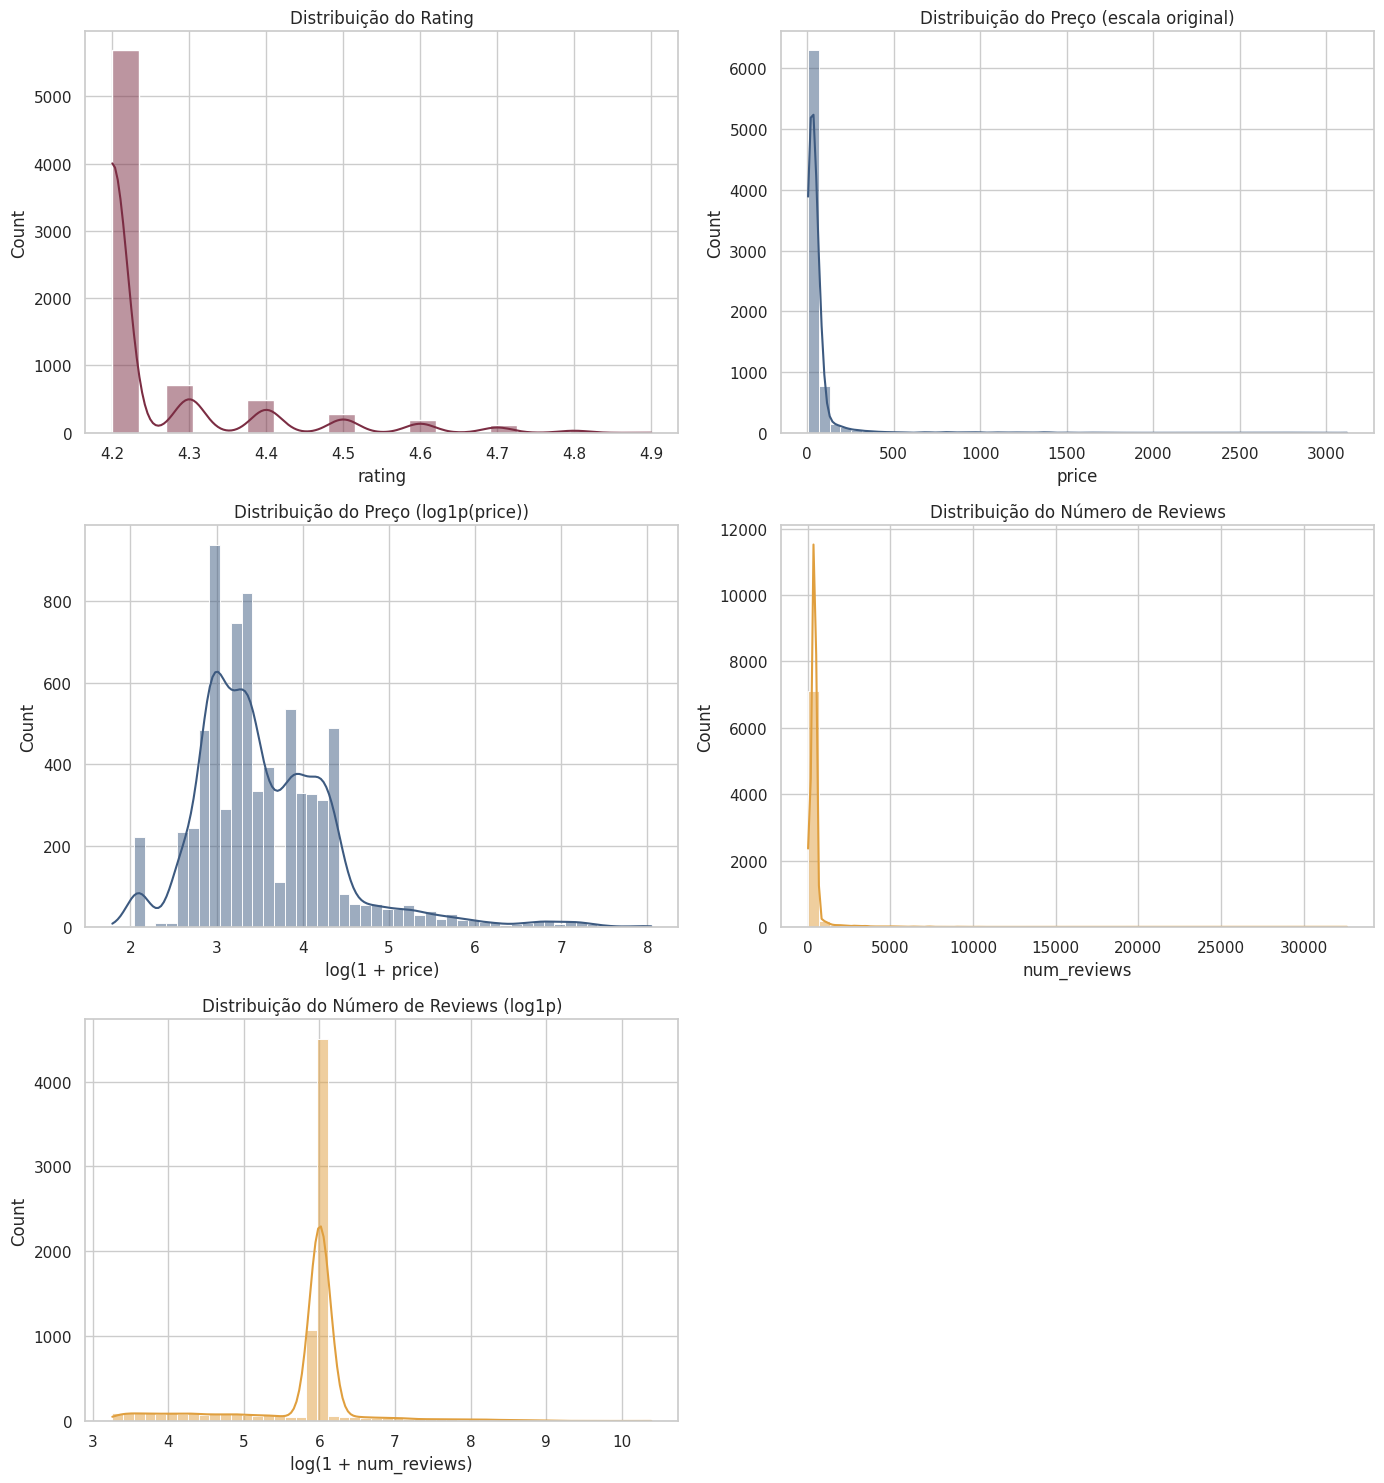

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# Rating
sns.histplot(df['rating'], bins=20, kde=True, ax=axes[0,0], color='#7b2d43')
axes[0,0].set_title('Distribuição do Rating')

# Price - Original
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0,1], color='#3d5a80')
axes[0,1].set_title('Distribuição do Preço (escala original)')

# Price - Log
sns.histplot(np.log1p(df['price']), bins=50, kde=True, ax=axes[1,0], color='#3d5a80')
axes[1,0].set_title('Distribuição do Preço (log1p(price))')
axes[1,0].set_xlabel('log(1 + price)')

# Num Reviews - Original
sns.histplot(df['num_reviews'], bins=50, kde=True, ax=axes[1,1], color='#e09f3e')
axes[1,1].set_title('Distribuição do Número de Reviews')

# Num Reviews - Log
sns.histplot(np.log1p(df['num_reviews']), bins=50, kde=True, ax=axes[2,0], color='#e09f3e')
axes[2,0].set_title('Distribuição do Número de Reviews (log1p)')
axes[2,0].set_xlabel('log(1 + num_reviews)')

# Remove o eixo extra [2,1] que ficará vazio
fig.delaxes(axes[2,1])

plt.tight_layout()
plt.show()

#### Insights: Variáveis Quantitativas
**Análise das Variáveis Quantitativas:**  
- **Year (Ano da Safra):** A distribuição mostra uma concentração significativa de vinhos da safra de 2011, indicando um possível ano de grande produção ou foco no dataset. Há uma cauda longa para anos mais antigos, mas a maioria dos vinhos é mais recente.
- **Rating (Avaliação Média):** A maioria dos vinhos possui uma avaliação muito alta, concentrada em 4.2. Existem poucos vinhos com avaliações mais baixas, o que sugere um dataset de vinhos de qualidade superior ou uma homogeneidade nas avaliações. Não há grande dispersão de valores.
- **Num Reviews (Número de Avaliações):** Esta variável apresenta uma distribuição bastante assimétrica à direita, com a maioria dos vinhos tendo um número baixo de avaliações. No entanto, há alguns vinhos com um número excepcionalmente alto de avaliações, indicando sua popularidade. O boxplot revela muitos outliers, que são vinhos muito populares.
- **Price (Preço):** Assim como `num_reviews`, o preço também é fortemente assimétrico à direita. A maioria dos vinhos tem preços mais acessíveis, mas existe uma cauda longa de vinhos caros e alguns outliers com preços muito elevados, o que é comum em mercados de vinhos finos.


---
## Fase 4 — Análise de Outliers
Nesta fase, utilizamos métodos estatísticos e visualizações para identificar valores atípicos (outliers) que podem representar vinhos de luxo, colecionáveis ou simplesmente erros de entrada de dados.

### 4.1 Identificação e Estatísticas de Outliers

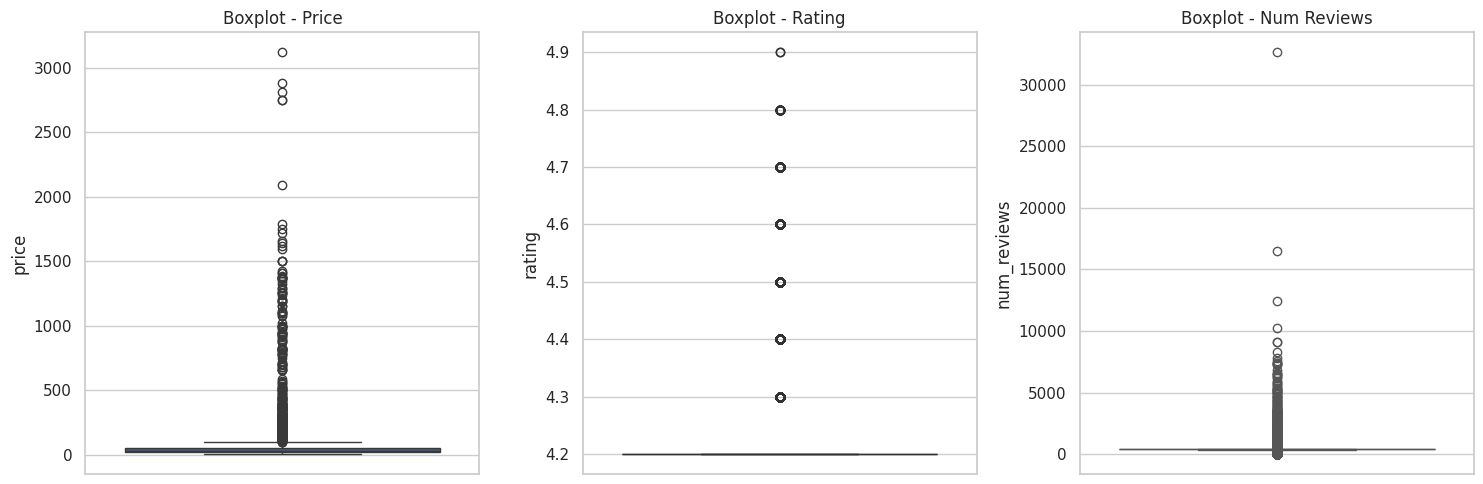

,limite_inferior,limite_superior,n_outliers,pct_outliers (%)
price,-29.78,100.02,538.0,7.17
rating,4.20,4.20,1821.0,24.28
num_reviews,350.00,454.00,1920.0,25.60


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.boxplot(y=df['price'], ax=axes[0], color='#3d5a80'); axes[0].set_title('Boxplot - Price')
sns.boxplot(y=df['rating'], ax=axes[1], color='#7b2d43'); axes[1].set_title('Boxplot - Rating')
sns.boxplot(y=df['num_reviews'], ax=axes[2], color='#e09f3e'); axes[2].set_title('Boxplot - Num Reviews')
plt.tight_layout()
plt.show()

def detectar_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    return outliers, lim_inf, lim_sup

resumo_outliers = {}
for col in ['price', 'rating', 'num_reviews']:
    outliers, li, ls = detectar_outliers_iqr(df[col])
    resumo_outliers[col] = {
        'limite_inferior': round(li, 2), 'limite_superior': round(ls, 2),
        'n_outliers': len(outliers), 'pct_outliers (%)': round(len(outliers)/len(df)*100, 2)
    }
pd.DataFrame(resumo_outliers).T

---
## Fase 5 - Análise multivariada

### 5.1 Relação entre Variáveis Quantitativas

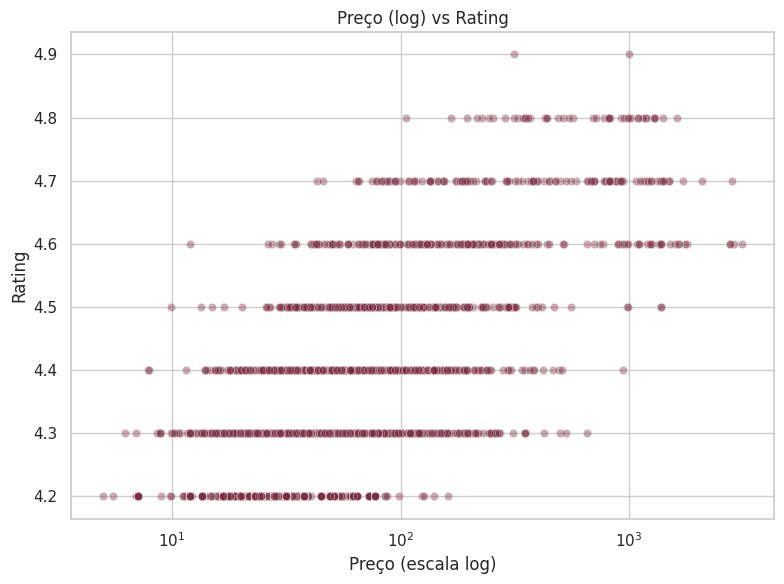

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='price', y='rating', alpha=0.4, color='#7b2d43')
plt.xscale('log')
plt.title('Preço (log) vs Rating')
plt.xlabel('Preço (escala log)')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

#### Insights: Relação Preço x Atributos Sensoriais
- ```body``` = 2.0 tem price_log de 4.0 (segundo mais caro).
- ```acidity``` = 1.0 tem price_log de 4.6, o mais caro de todas as categorias do gráfico inteiro.


In [22]:
#corr_df = df.select_dtypes(include=['float64', 'int64'])

#corr = corr_df.corr()

#plt.figure(figsize=(12, 8))
#sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
#plt.title('Matriz de Correlação')
#plt.show()

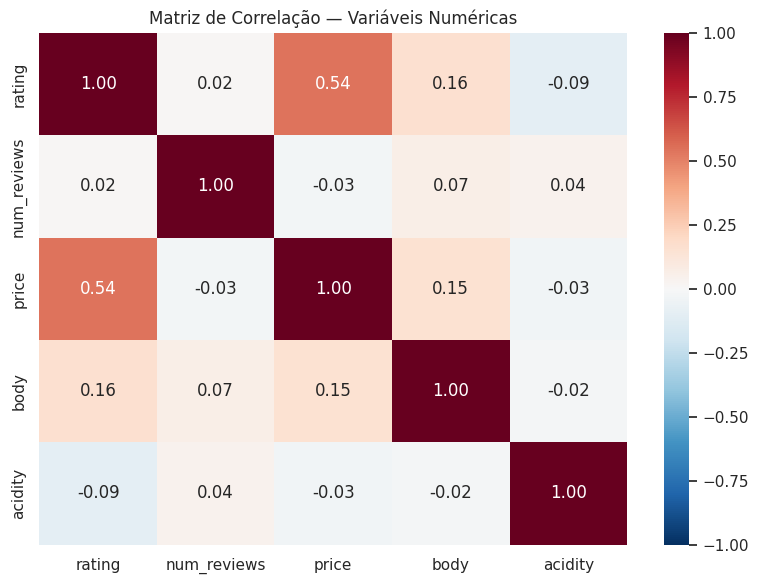

In [23]:
corr = df[['rating', 'num_reviews', 'price', 'body', 'acidity']].corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Matriz de Correlação — Variáveis Numéricas')
plt.tight_layout()
plt.show()

#### Insights: Correlação e Tempo
* **Year X Rating**: A qualidade do vinho possui relação negativa moderada com o ano em que o * vinho foi feito(essa relação não é suficientemente forte para afirmar que vinhos antigos recebem avaliações maiores). : -0,3
* **Year X log_preço**: Apresentou uma correlação negativa alta sugerindo que vinhos mais antigos tendem a ser mais caros
* **Rating X log_Preço**: Indicando que vinhos com melhores avaliações tendem a apresentar preços mais elevados


O preço do vinho possui uma correlação forte com a qualidade do vinho(Isso significa que, em geral, produtos mais bem avaliados tendem a possuir preços mais elevados), e possui correlação negativa moderada com a variavel de ano que o vinho foi produzido (Isso indica que produtos de anos mais antigos tendem a apresentar preços mais elevados.).

A quantidade de reviews se relaciona de maneira muito fraca quase nula com a qualidade de  vinhos e com o ano em que ele foi produzido (A quantidade de avaliações não parece influenciar diretamente a nota média do produto), e se relaciona de maneira negativa quase nula com o preço (Isso indica que produtos caros podem possuir poucas avaliações, enquanto produtos baratos podem receber milhares de avaliações)

A quantidade de reviews tambem se relaciona de maneira muito fraca positivamente com a o ano em que o vinho foi produzido

A qualidade do vinho possui relação negativa moderada com o ano em que o vinho foi feito(essa relação não é suficientemente forte para afirmar que vinhos antigos recebem avaliações maiores.).


### 5.2 Relação entre Variáveis Qualitativas (Contingência)

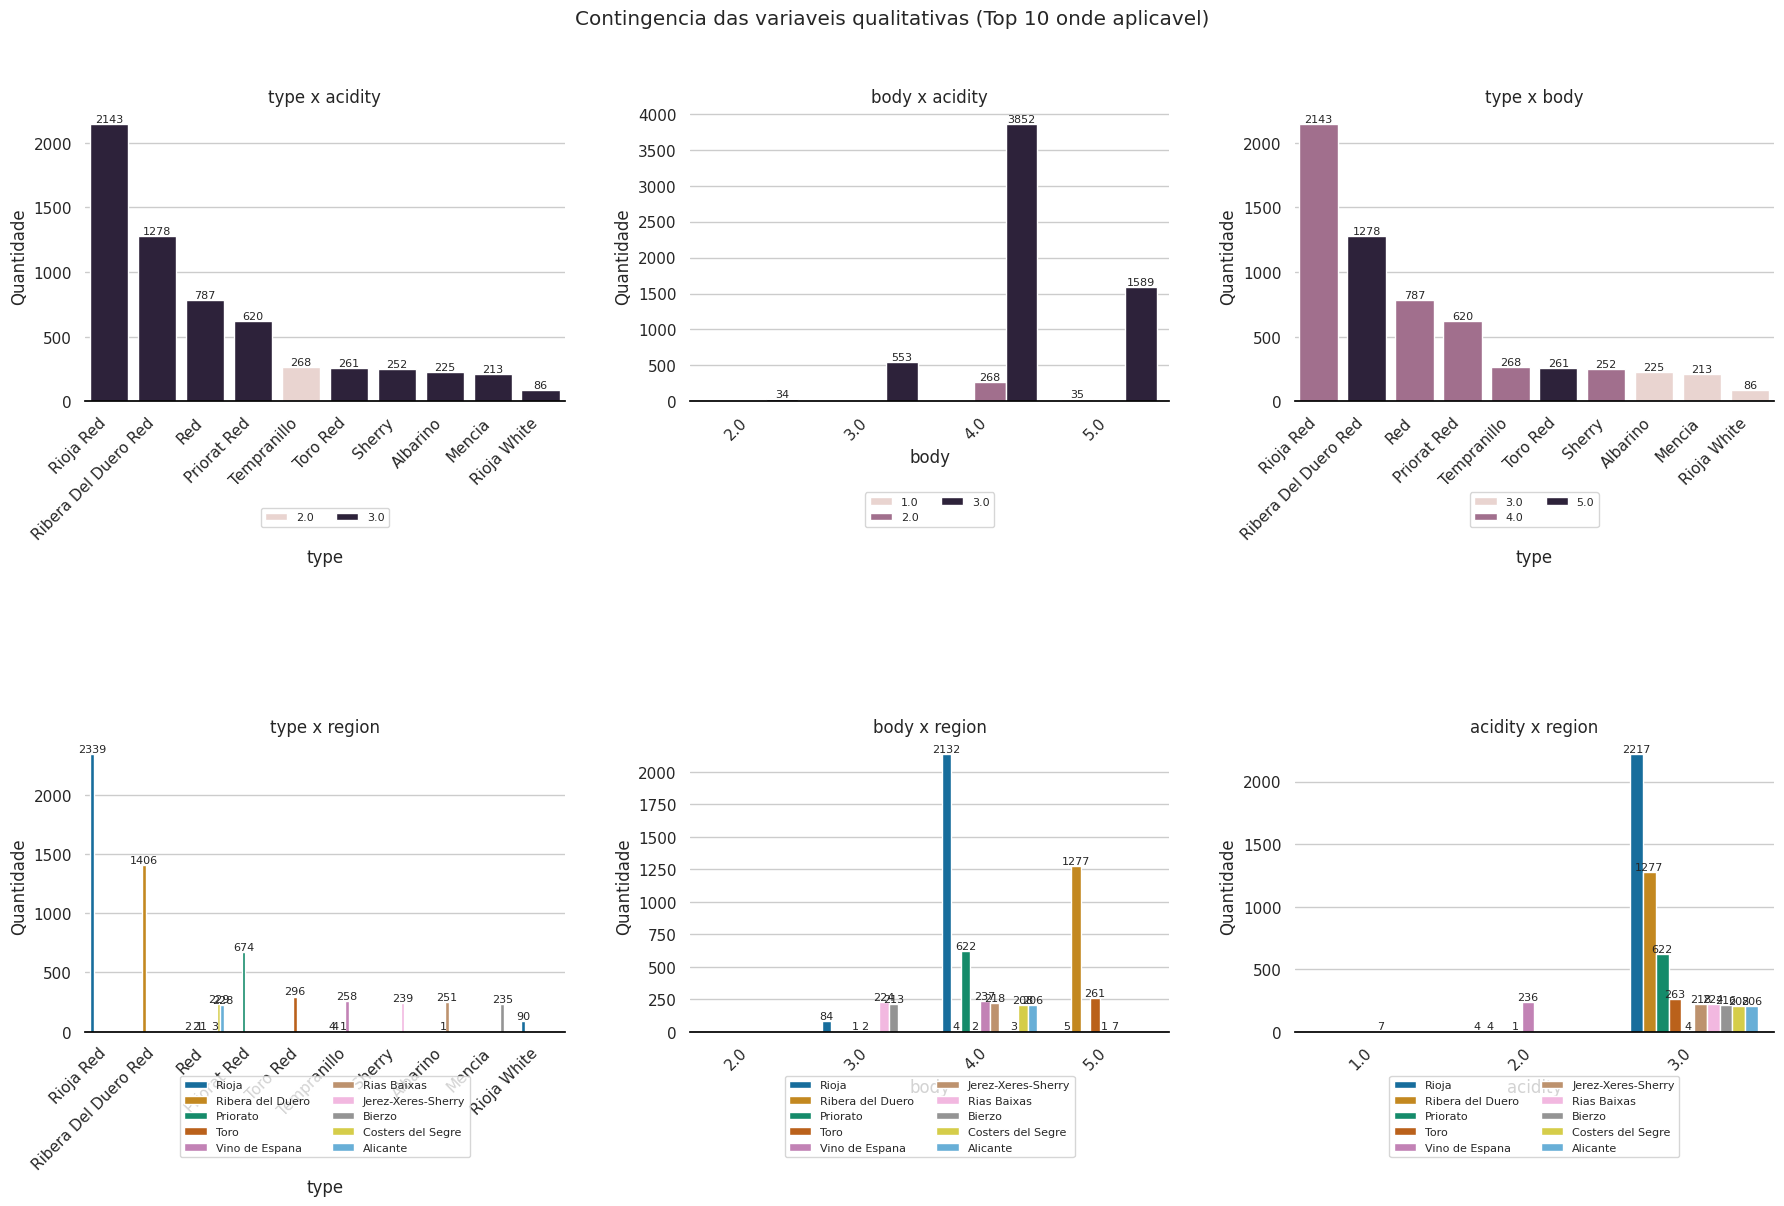

In [24]:
# @title Contingencia
sns.set_style('whitegrid')

variaveis_qualitativas = ['type', 'body', 'acidity', 'region']

combinacoes = sorted(
    itertools.combinations(variaveis_qualitativas, 2),
    key=lambda x: x[1]
)

ordens_fixas = {
    'body': sorted(df['body'].dropna().unique()),
    'acidity': sorted(df['acidity'].dropna().unique()),
}

def get_order(var, base_df):
    if var in ordens_fixas:
        return ordens_fixas[var]
    n_unique = base_df[var].nunique()
    if n_unique > 10:
        return base_df[var].value_counts().nlargest(10).index.tolist()
    return sorted(base_df[var].dropna().unique().tolist())

fig, axes = plt.subplots(figsize=(18, 12), ncols=3, nrows=2, squeeze=False)
axes = axes.flatten()

for i, (var_1, var_2) in enumerate(combinacoes):
    df_pair = df[[var_1, var_2]].dropna().copy()
    for v in (var_1, var_2):
        if isinstance(df_pair[v].dtype, pd.CategoricalDtype):
            df_pair[v] = df_pair[v].astype(str)

    order = get_order(var_1, df_pair)
    hue_order = get_order(var_2, df_pair)

    df_pair = df_pair[df_pair[var_1].isin(order) & df_pair[var_2].isin(hue_order)]

    ax = sns.countplot(
        data=df_pair, x=var_1, hue=var_2, ax=axes[i],
        order=order, hue_order=hue_order,
    )
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", fontsize=8)

    ax.set(
        title=f"{var_1} x {var_2}",
        ylabel="Quantidade"
    )
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')

    for side in ["left", "top", "right"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("black")

    sns.move_legend(
        axes[i], "lower center",
        bbox_to_anchor=(.5, -.45), ncol=2, fontsize=8, title=None,
    )

plt.suptitle("Contingencia das variaveis qualitativas (Top 10 onde aplicavel)", y=1.02)
plt.tight_layout(h_pad=8, w_pad=3)
plt.show()

### 5.3 Cruzamento Quali-Quanti e Análise Multivariada

In [25]:
if 'num_reviews_log' not in df.columns:
    df['num_reviews_log'] = np.log1p(df['num_reviews'])

if 'price_log' not in df.columns:
    df['price_log'] = np.log1p(df['price'])

print("Colunas criadas com sucesso! Colunas atuais:", df.columns.tolist())

Colunas criadas com sucesso! Colunas atuais: ['winery', 'wine', 'year', 'rating', 'num_reviews', 'country', 'region', 'price', 'type', 'body', 'acidity', 'year_num', 'is_non_vintage', 'type_clean', 'body_missing', 'acidity_missing', 'num_reviews_log', 'price_log']


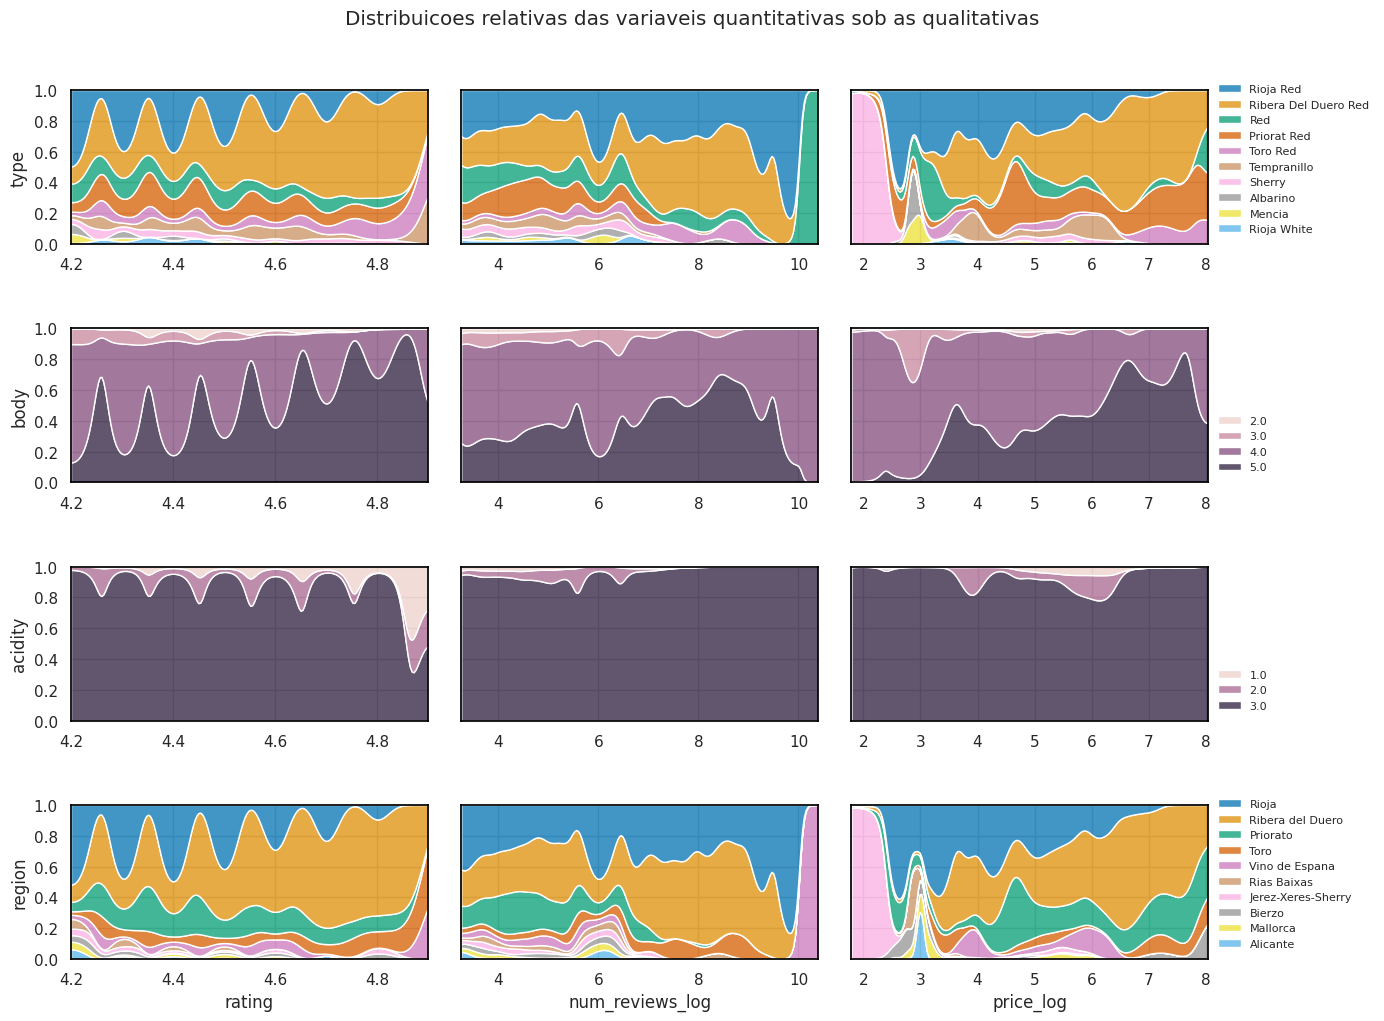

In [26]:
import numpy as np
# @title Distribuição relativa
variaveis_qualitativas = ['type', 'body', 'acidity', 'region']
variaveis_quantitativas = ['rating', 'num_reviews_log', 'price_log']

# Create the log-transformed columns if they don't exist
if 'num_reviews_log' not in df.columns:
    df['num_reviews_log'] = np.log1p(df['num_reviews'])
if 'price_log' not in df.columns:
    df['price_log'] = np.log1p(df['price'])

ordens_fixas = {
    'body': sorted(df['body'].dropna().unique()),
    'acidity': sorted(df['acidity'].dropna().unique()),
}

def get_order(var, base_df):
    if var in ordens_fixas:
        return ordens_fixas[var]
    n_unique = base_df[var].nunique()
    if n_unique > 10:
        return base_df[var].value_counts().nlargest(10).index.tolist()
    return sorted(base_df[var].dropna().unique().tolist())

def kde_plot(df, x, y, axe, i, ncols):
    df_pair = df[[x, y]].dropna().copy()
    if isinstance(df_pair[x].dtype, pd.CategoricalDtype):
        df_pair[x] = df_pair[x].astype(str)

    order = get_order(x, df_pair)
    df_pair = df_pair[df_pair[x].isin(order)]

    legend = True if ((i + 1) % ncols == 0) else False
    ax = sns.kdeplot(
        data=df_pair, x=y, hue=x, hue_order=order, cut=0,
        multiple="fill", ax=axe, legend=legend
    )
    ax.set(
        ylabel=x,
        xlabel=y if i >= len(variaveis_qualitativas) * len(variaveis_quantitativas) - ncols else "",
    )
    for side in ["left", "top", "right", "bottom"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("black")
    if legend:
        sns.move_legend(
            axe, "lower left", ncol=1, title=None, fontsize=8,
            bbox_to_anchor=(1, 0), frameon=False
        )

combinacoes = list(itertools.product(variaveis_qualitativas, variaveis_quantitativas))

ncols = 3
nrows = -(-len(combinacoes) // ncols)

fig, axes = plt.subplots(figsize=(14, 10), ncols=ncols, nrows=nrows, squeeze=False, sharey=True)
axes = axes.flatten()

for i, (var_qualitativa, var_quantitativa) in enumerate(combinacoes):
    kde_plot(df, var_qualitativa, var_quantitativa, axes[i], i, ncols)

for j in range(len(combinacoes), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuicoes relativas das variaveis quantitativas sob as qualitativas', y=1.02)
plt.tight_layout(h_pad=3, w_pad=2)
plt.show()

#### Insights: Distribuição Relativa e Segmentação
- type × price_log: dá pra ver que Priorat Red domina a faixa de preço alto (acima de ~6-7), enquanto Rioja Red e Tempranillo dominam preços baixos.
- body × price_log: fica claro que vinhos de preço baixo (log ~ 2-3) são quase todos body 3.0/4.0, e a partir de log~ 5 o body 4.0/5.0 sugere que "corpo" está associado a preço, coerente com a correlação de 0.30 que vimos na matriz.
- region × num_reviews_log: no miolo da distribuição (log 5-7) há bastante mistura de regiões, mas nas caudas (poucos reviews e muitos reviews) Rioja domina — pode indicar que Rioja tem tanto os vinhos mais nichados quanto os mais populares do dataset.


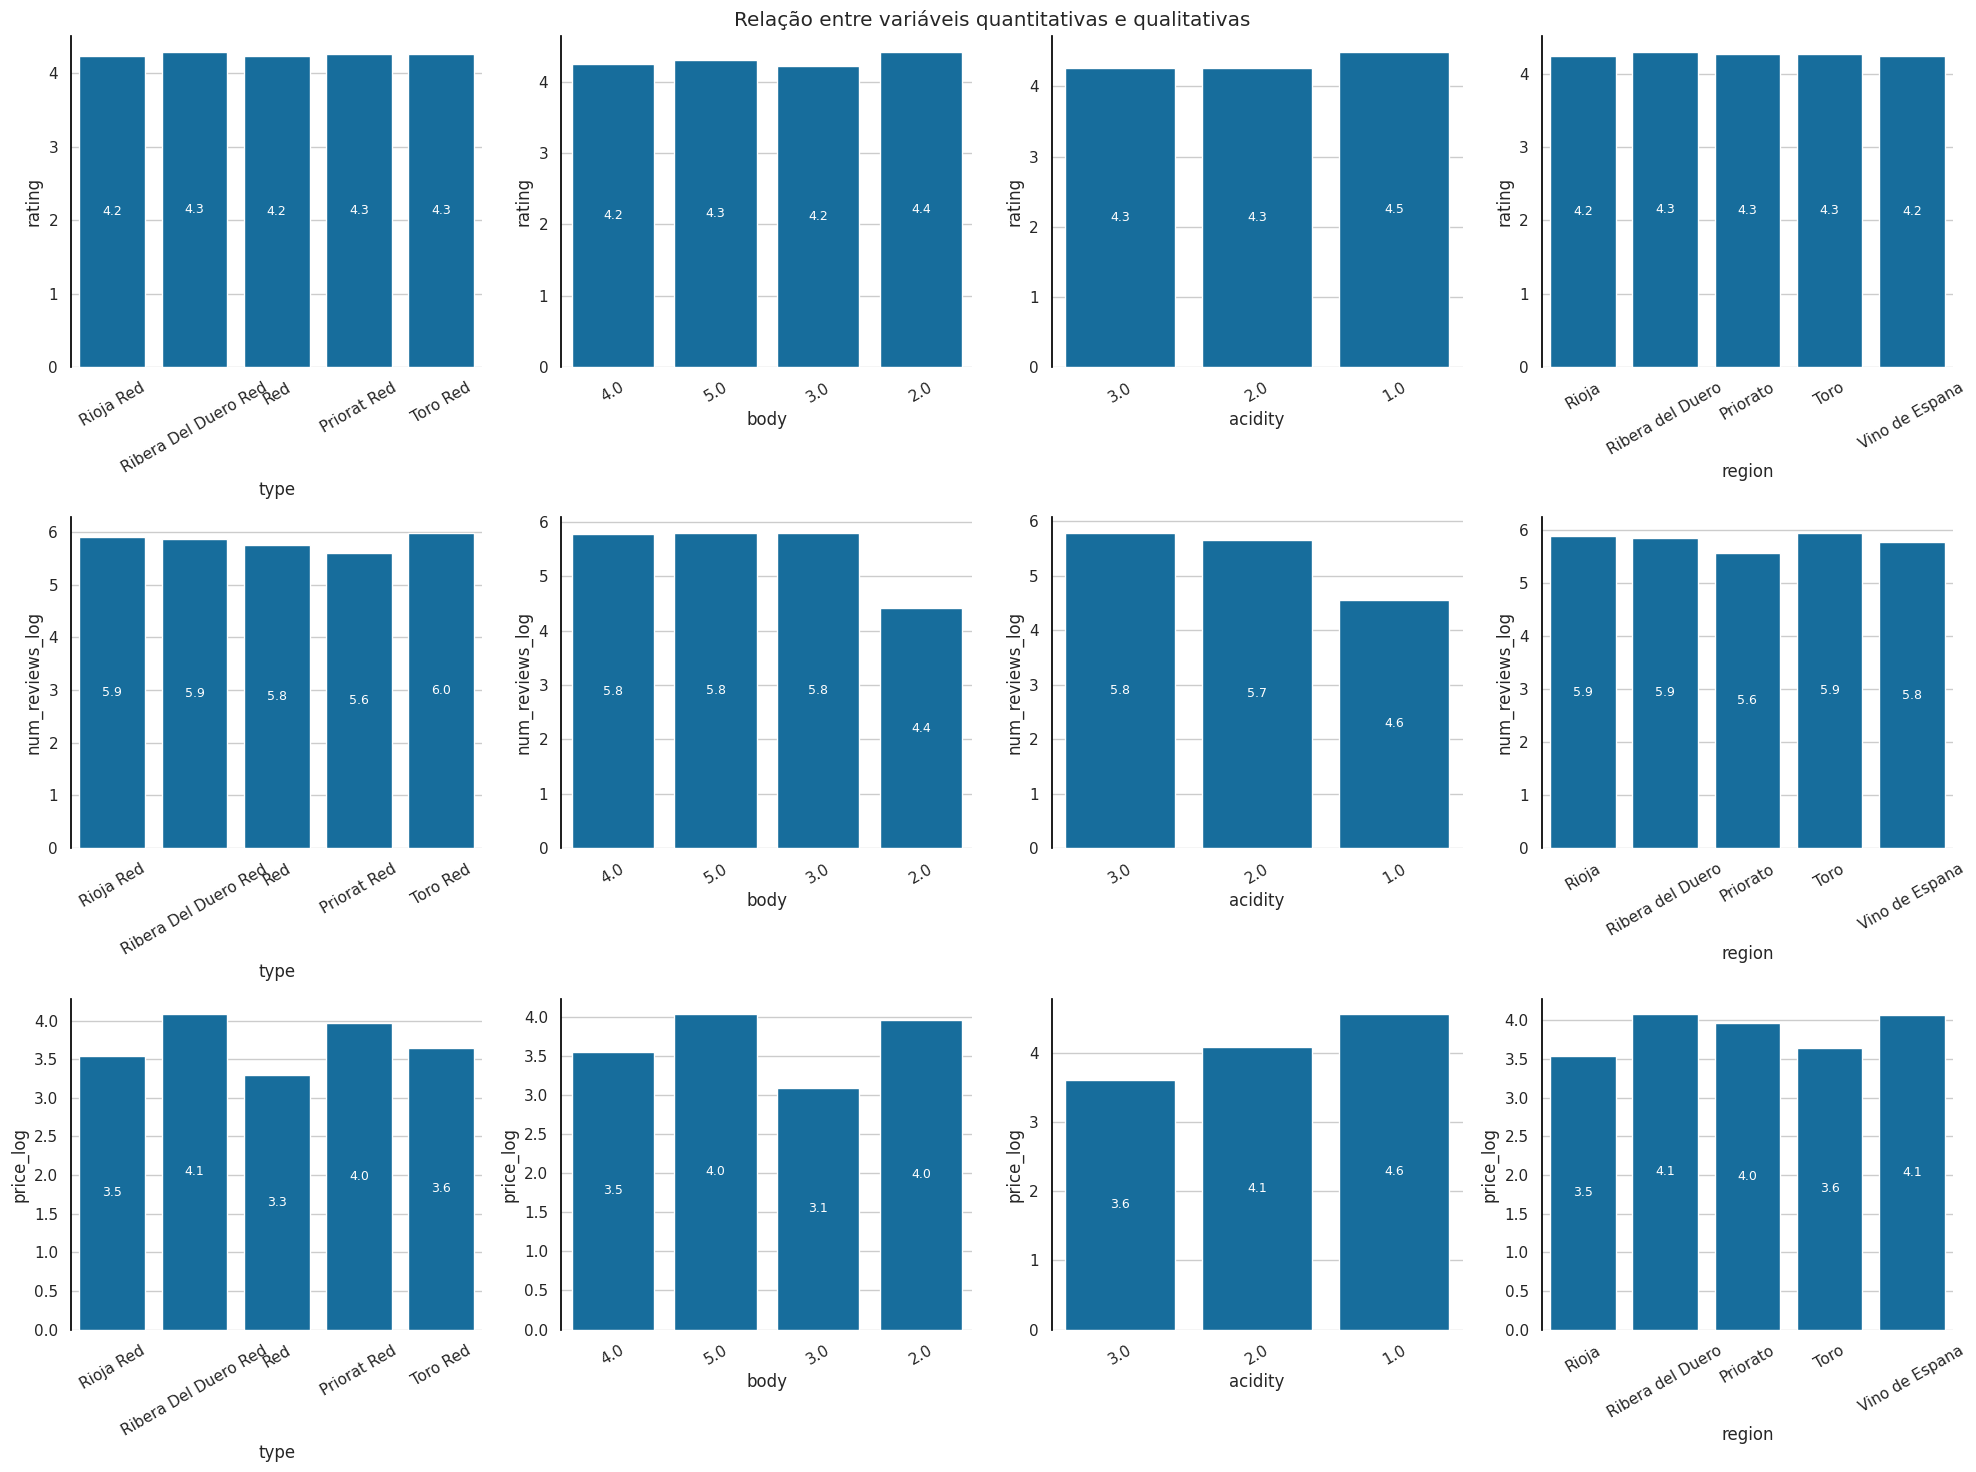

In [27]:
combinacoes = list(itertools.product(variaveis_quantitativas, variaveis_qualitativas))

def top_n_categorias(serie, n=5):
    """Retorna a lista das n categorias mais frequentes, em ordem decrescente."""
    return serie.value_counts().iloc[:n].index.tolist()

fig, axes = plt.subplots(figsize=(20,15), ncols=4, nrows=3, squeeze=False)
axes = axes.flatten()

for i, (var_quantitativa, var_qualitativa) in enumerate(combinacoes):
    order = top_n_categorias(df[var_qualitativa], n=5)
    df_filtrado = df[df[var_qualitativa].isin(order)]  # opcional, mas evita recalcular estatística com o resto

    ax = sns.barplot(
        data=df_filtrado, x=var_qualitativa, y=var_quantitativa,
        ax=axes[i], order=order, estimator="mean", errorbar=None
    )
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", color="white", label_type="center", fontsize=9)

    for side in ["bottom", "top", "right"]:
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color("black")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Relação entre variáveis quantitativas e qualitativas")
plt.tight_layout()
plt.show()

#### Insights: Médias Quantitativas por Categoria
- Pouca variação entre categorias (tudo entre 4.2 e 4.5)
- ```body``` = 2.0 tem rating médio de 4.4, o mais alto entre os bodies.
- ```acidity``` = 1.0 tem rating médio de 4.5, o mais alto entre as acidezes.


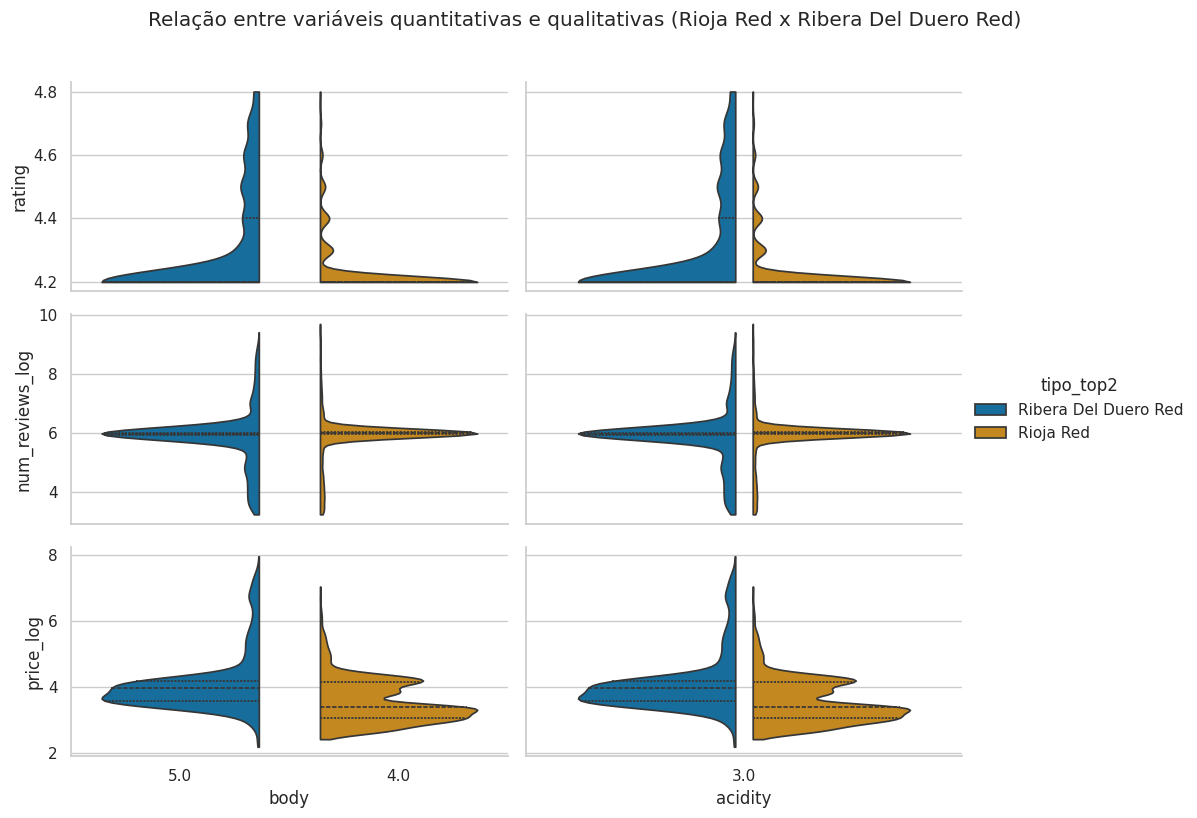

In [29]:
import numpy as np
# @title Distribuição conjunta

# Filtra os dois tipos mais frequentes para comparação
top2_tipos = df['type'].value_counts().head(2).index.tolist()
df_plot = df[df['type'].isin(top2_tipos)].copy()
df_plot['tipo_top2'] = df_plot['type']

variaveis_quantitativas = ['rating', 'num_reviews_log', 'price_log']
variaveis_qualitativas_pairgrid = ['body', 'acidity']

cols_necessarias = variaveis_quantitativas + variaveis_qualitativas_pairgrid + ['tipo_top2']
df_plot = df_plot[cols_necessarias].dropna().copy()
df_plot['body'] = df_plot['body'].astype(str)
df_plot['acidity'] = df_plot['acidity'].astype(str)

g = sns.PairGrid(
    df_plot, y_vars=variaveis_quantitativas, x_vars=variaveis_qualitativas_pairgrid,
    hue='tipo_top2', height=3
)
g.fig.set_size_inches(10, 8)
g.map(sns.violinplot, split=True, inner="quart", gap=.1, cut=0)

plt.suptitle('Relação entre variáveis quantitativas e qualitativas (Rioja Red x Ribera Del Duero Red)', y=1.02)
plt.tight_layout()
g.add_legend()
plt.show()

#### Insights: Popularidade vs Características
- ```body``` = 2.0 tem num_reviews_log médio de 4.4, muito abaixo dos outros bodies (5.6-6.0).
- ```acidity``` = 1.0 tem num_reviews_log médio de 4.6, também bem abaixo dos demais (5.7-5.8).


---
## Fase 6 — Síntese
Consolidamos todos os achados da análise em insights acionáveis e respostas diretas para as perguntas de negócio formuladas no início do projeto.

### 6.1 Consolidação dos Principais Insights

**1. Concentração geográfica extrema**
`country` é 100% Espanha e ~65% dos vinhos vêm de apenas duas regiões: Rioja e Ribera del Duero.

**2. Preço e avaliação andam juntos**
Correlação `price_log` × `rating` = 0.65. Vinhos mais caros tendem a ter notas mais altas.

**3. Safra antiga = preço mais alto**
Correlação `year` × `price_log` = -0.56. Vinhos de safras mais antigas custam mais.

**4. Menos reviews, nota mais alta**
Correlação `num_reviews_log` × `rating` = -0.44. Vinhos com poucas avaliações tendem a ter ratings mais altos.

**5. Priorat domina os preços mais altos**
Priorat Red assume a maior fatia na cauda de preços elevados no dataset.

### 6.2 Respostas às Perguntas de Negócio

| Pergunta | Resposta e Evidência |
|---|---|
| Preço está relacionado à nota? | Sim, correlação forte de 0.65. Qualidade percebida é um driver de valor. |
| Quais regiões concentram vinhos caros? | Priorat Red e vinhos de Rioja com alto corpo (body 4-5). |
| Existe viés de concentração? | Sim, Rioja domina o dataset (2440 registros), indicando foco em regiões tradicionais. |
| Vinhos antigos são mais caros? | Sim, há uma tendência clara de valorização por envelhecimento (safra vs preço). |

### 6.3 Próximos Passos
* **Modelagem Preditiva**: Desenvolver um modelo para prever o preço do vinho baseado em características sensoriais e ano.
* **Clusterização**: Agrupar vinhos por perfil (ex: vinhos populares vs vinhos de investimento).
* **Análise de Sentimento**: Se disponível, analisar o texto das avaliações para refinar a variável `rating`.